1. Load Model
2. Load target data.
3. Compute model's classification probabilities.
4. Compare classification probalities to actual classifications using Gains approach.

# Load Necessary Tools
Vizualization References
[Pandas](http://pandas.pydata.org/pandas-docs/stable/visualization.html),
[Seaborn](https://seaborn.pydata.org/)

In [13]:
# Ensure Cuda is in Path
# !echo $PATH

# Import Helper Libraries
import churn_utilities
import churn_io

# Reload Tweaked/Edited Helper Libraries 
import importlib
importlib.reload(churn_utilities)
importlib.reload(churn_io)
from churn_utilities import *
from churn_io import *

# Initialize Run Tracker
RUN=1
# Data Sci 
import pandas as pd
import numpy as np
from sklearn import metrics # roc_curve, roc_auc_score, auc, average_precision_score
from scipy.stats import boxcox

# ML
import tensorflow as tf

# OS
from subprocess import call

# Viz
%matplotlib inline
import matplotlib
matplotlib.style.use('ggplot')
from matplotlib import pyplot as plt
from pandas.tools.plotting import scatter_matrix
import time

# Import Data, Define Additional Vars

In [383]:
# Only run this cell if necessary
new_data_necessary=True
if new_data_necessary:
    print("It's Necessary!")
    df = churn_io.from_redshift()
    data = churn_io.split_data(df)
    churn_io.split_data_to_file(data)

It's Necessary!


In [2]:
def get_data(tr=None, bins=False, write=False, verbose=False, fnorm="fn11", threshold=2):
    
    # Standardize transformation key
    tr = tr[0:3].lower()
    
    # Get data
    print("Retrieving saved query data.")
    x_train_raw, y_train, x_valid_raw, y_valid, x_test_raw, y_test = churn_io.split_data_from_file()
    
    tr_dict = {'box': 'Boxing!', 'log': "Logging!", 
               'rec': 'Reciprocating!', None: 'Not Transforming!'}
    print(tr_dict[tr])

    x_train, x_valid, x_test = condition_data(x_train_raw.copy(), x_valid_raw.copy(), x_test_raw.copy(), trans=tr, threshold=threshold, verbose=verbose)
    print("Tranform Complete!\nBeginning rescale...")
    #churn_io.split_data_to_file((x_train_box, x_valid_box, x_test_box), prefix="box_")

    x_train, x_valid, x_test = rescale_data(x_train.copy(), x_valid.copy(), x_test.copy(), fnorm=fnorm, threshold=2, bins=bins, verbose=verbose)
    print("Scaling Complete!")
    
    return x_train, y_train, x_valid, y_valid, x_test, y_test

    

In [3]:
x_train, y_train, x_valid, y_valid, x_test, y_test = get_data(tr='rec', bins=0, threshold=2)

Retrieving saved query data.
Reciprocating!
vod_v1 59
vod_v2 59
vod_acc 100
nxt_v1 159
nxt_v2 143
nxt_acc 217
num_vol_losses 15
pmt_pct_days_paid 120902
num_pmts 42
pct_ppv1 29271
num_invol_fail 65
vod_lst_30days 31
vod_lst_30to60days 31
vod_lst_60to90days 31
nxt_view_ep_lst_90days 127
nxt_view_ep_lst_30days 91
nxt_lst_30to60days 84
nxt_lst_60to90days 70
num_strms_vshp_all 4076
vod_num_strms 3884
num_nc_em_rcvd_1st_60days 24
overall_num_device_types 18
num_strms_vshp_net_orig 1168
num_strms_vshp_ring 1838
avg_rebuf_ratio_lst_30days 6064
avg_rebuf_ratio_lst_60days 5950
avg_rebuf_ratio_lst_90days 5999
Tranform Complete!
Beginning rescale...
Scaling Complete!


## Gain Plots

1.  Order (y_pred, churn=y_valid (or y_test)) by y_pred
2.  Break into deciles 
3.  For each decile:
    - record exact population size
    - record number of churners
    - compute churn rate (churners/popSize)
    - compute % of all churners (theseChurners/allChurners)
    - compute cumaltive % of churners
    - show what cumalative % of churners would be if groups were randomly selected from general population

Can also record number of predicted churners...

In [187]:
# 0. Choose y_valid or y_test

# UPDATE: 2017-05-04:
#   -- new code means that we have to restore ckpt model data before this...
#   -- doing other stuff now / update this section later

y_set = 'Valid'  # 'valid' or 'test'
if y_set=='Valid': 
    y_actual = y_valid
    y_pred   = sess.run(y_model, feed_dict = {x_feed: xx_valid})
else:
    y_actual = y_test
    y_pred   = sess.run(y_model, feed_dict = {x_feed: xx_test})


# 1. Order (y_pred, churn=y_valid (or y_test)) by y_pred
sortIndex      =  np.argsort(y_pred[:,0])
sortIndex      =  sortIndex[::-1]
y_pred_sorted  =  y_pred[sortIndex,0]
y_sorted       =  y_actual[sortIndex,0]

# 2. Break y_pred and churn arrays into deciles 
#    -- since arrays are same length, np.array_split() splits them
#       into same-sized groups (all equal if possible)
y_pred_deciles = np.array_split(y_pred_sorted, 10)
y_deciles      = np.array_split(y_sorted, 10)


# 3. Record decile properties 
# - Population size for each decile
decile = np.linspace(1,10,10)
decile_size = np.array([len(decile) 
                        for decile in y_pred_deciles])
# - Number of actual churners in each decile
num_churners = np.array([sum(decile) 
                         for decile in y_deciles])
# - Churn Rate (churners/popSize)
churn_rate = np.array([round(100*n_churn/decile_size[i],1)
                       for i,n_churn in enumerate(num_churners)])
# - Number of All Churners
all_churners = np.repeat(np.sum(num_churners), 10)
# - Decile's Churner Stock:  num_churners / all_churners
proportion_of_churn = np.array([round(100*n_churn/all_churners[0],2) 
                          for n_churn in num_churners])
# - Cumulative sum of Churner Stock
cum_prop = np.cumsum(proportion_of_churn)
# - Cumulative sum of Churner Stock if Deciles were randomized groups
cum_control = np.linspace(10,100,10)

# Generate Pandas DataFrame
churnTable = pd.DataFrame({
    'decile': decile,
    'size': decile_size,
    'num_churn': num_churners,
    'churn_rate': churn_rate,
    'all_churn': all_churners,
    'proportion_of_churn': proportion_of_churn,
    'cum_prop': cum_prop,
    'cum_control': cum_control
})
churnTable=churnTable[['decile','size','num_churn','churn_rate','all_churn','proportion_of_churn','cum_prop','cum_control']]

In [158]:
#plt.plot(y_pred[indices,0])
#fileName='name'
#churnTable.to_csv('Model-Data/'+fileName+'.csv')
churnTable

,decile,size,num_churn,churn_rate,all_churn,proportion_of_churn,cum_prop,cum_control
0,1.0,16012,3869.0,24.2,11350.0,34.09,34.09,10.0
1,2.0,16011,1813.0,11.3,11350.0,15.97,50.06,20.0
2,3.0,16011,1318.0,8.2,11350.0,11.61,61.67,30.0
3,4.0,16011,1077.0,6.7,11350.0,9.49,71.16,40.0
4,5.0,16011,886.0,5.5,11350.0,7.81,78.97,50.0
5,6.0,16011,764.0,4.8,11350.0,6.73,85.70,60.0
6,7.0,16011,578.0,3.6,11350.0,5.09,90.79,70.0
7,8.0,16011,455.0,2.8,11350.0,4.01,94.80,80.0
8,9.0,16011,343.0,2.1,11350.0,3.02,97.82,90.0
9,10.0,16011,247.0,1.5,11350.0,2.18,100.00,100.0


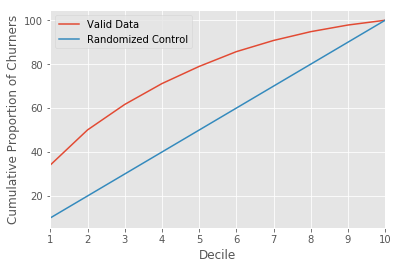

In [159]:
#plt.plot(churnTable['cum_stock'])
#plt.plot(churnTable['cum_stock_control'])
#churnTable['cum_prop'].plot()
#churnTable['cum_control'].plot()
fig = churnTable.plot(x='decile',y=['cum_prop','cum_control'])
fig.set_xlabel('Decile')
fig.set_ylabel('Cumulative Proportion of Churners')
fig.legend(labels=[y_set+' Data', 'Randomized Control'])

In [134]:
path2fig  = "/path/to/project/Figures/"
fileName = time.strftime("%Y-%m-%d") + "__19nsig-1nsig_lr005-bs250-ep7_BoxExl+M_Test"
fig.get_figure().savefig(path2fig+fileName+".png")


In [278]:
print(len(x_train.jan))
print("Jan:",(x_train.jan==1).sum())
print("Feb:",(x_train.feb==1).sum())
print("Mar:",(x_train.mar==1).sum())
print("Apr:",(x_train.apr==1).sum())
print("Jun:",(x_train.jun==1).sum())
print("")
print("Rumble:",(x_train.rumble30==1).sum())
print("Mania:",(x_train.mania30==1).sum())
print("Slam:",(x_train.slam30==1).sum())
print("Survivor:",(x_train.survivor30==1).sum())

569283
Jan: 32655
Feb: 39700
Mar: 21331
Apr: 35215
Jun: 48875

Rumble: 58609
Mania: 47144
Slam: 82717
Survivor: 53234


In [135]:
# Save Training Checkpoint?
path2ckpt = "/path/to/project/Model-Ckpt/"
saver.save(sess,path2ckpt+fileName)

In [160]:
#-----------------------------------------------------
# Close TF Session (if you haven't already!)
#-----------------------------------------------------
sess.close()
